In [1]:
SEED = 2137

import pandas as pd
import numpy as np
import seaborn as sb

data = pd.read_csv("data/domy.csv", decimal='.')
data[data == '?'] = pd.NA
print(data.info())
data.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Id             1460 non-null   int64
 1   MSSubClass     1460 non-null   int64
 2   MSZoning       1460 non-null   str  
 3   LotFrontage    1201 non-null   str  
 4   LotArea        1460 non-null   int64
 5   Street         1460 non-null   str  
 6   Alley          91 non-null     str  
 7   LotShape       1460 non-null   str  
 8   LandContour    1460 non-null   str  
 9   Utilities      1460 non-null   str  
 10  LotConfig      1460 non-null   str  
 11  LandSlope      1460 non-null   str  
 12  Neighborhood   1460 non-null   str  
 13  Condition1     1460 non-null   str  
 14  Condition2     1460 non-null   str  
 15  BldgType       1460 non-null   str  
 16  HouseStyle     1460 non-null   str  
 17  OverallQual    1460 non-null   int64
 18  OverallCond    1460 non-null   int64
 19  YearBuilt      14

,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,10516.828082,6.099315,5.575342,1971.267808,1984.865753,443.639726,46.549315,567.240411,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,9981.264932,1.382997,1.112799,30.202904,20.645407,456.098091,161.319273,441.866955,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,223.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,383.500000,0.000000,477.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,712.250000,0.000000,808.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,5644.000000,1474.000000,2336.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [2]:
data = data.drop("Id", axis="columns")
data = data[data["GrLivArea"] < 4_000]

In [3]:
data = data.drop("Alley", axis="columns") # to many '?'

In [4]:
data = data.drop("Utilities", axis="columns") # little distinct values
data = data.drop("Condition2", axis="columns") # little distinct values
data = data.drop("RoofMatl", axis="columns") # little distinct values
data = data.drop("Fence", axis="columns") # little distinct values
data = data.drop("MasVnrType", axis="columns") # insignificant
data = data.drop("MasVnrArea", axis="columns") # insignificant

data = data.drop("BsmtFinType1", axis="columns") # insignificant, covered by BsmtUnfSF and TotalBsmtSF
data = data.drop("BsmtFinSF1", axis="columns") # insignificant,  covered by BsmtUnfSF and TotalBsmtSF
data = data.drop("BsmtFinType2", axis="columns") # insignificant,  covered by BsmtUnfSF and TotalBsmtSF
data = data.drop("BsmtFinSF2", axis="columns") # insignificant,  covered by BsmtUnfSF and TotalBsmtSF

data = data.drop("Electrical", axis="columns") # insignificant, dependent on year built

In [5]:
def fill_missing(column, method='interp'):
    if method == 'fill':
        data[column] = data[column].ffill()
        data[column] = data[column].bfill()
    else:
        data[column] = data[column].interpolate()

def qual_to_val(column, mapping):
    data[column] = data[column].map(mapping)
    data[column] = pd.to_numeric(data[column])
    fill_missing(column)

In [6]:
qual_to_val("LotShape", {"Reg": 4, "IR1": 3, "IR2": 2, "IR3": 1})
qual_to_val("CentralAir", {"Y": 1, "N": 0})
qual_to_val("GarageFinish", {"Fin": 3, "RFn": 2, "Unf": 1, pd.NA: 0})
qual_to_val("PavedDrive", {"Y": 2, "P": 1, "N": 0})


In [7]:
for col in ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]:
    qual_to_val(col, {"Ex": "6", "Gd": "5", "TA": "4", "Fa": "3", "Po": "2", "NA": "0", pd.NA: "0"})

def pytajniki(column):
    data[column] = pd.to_numeric(data[column])
    fill_missing(column)

for col in ["LotFrontage", "GarageYrBlt"]:
    pytajniki(col)

data["MSSubClass"] = data["MSSubClass"].astype(str)

data["PricePerLivArea"] = data["SalePrice"] / data["GrLivArea"]

data = pd.get_dummies(data, dtype=int)


<Axes: >

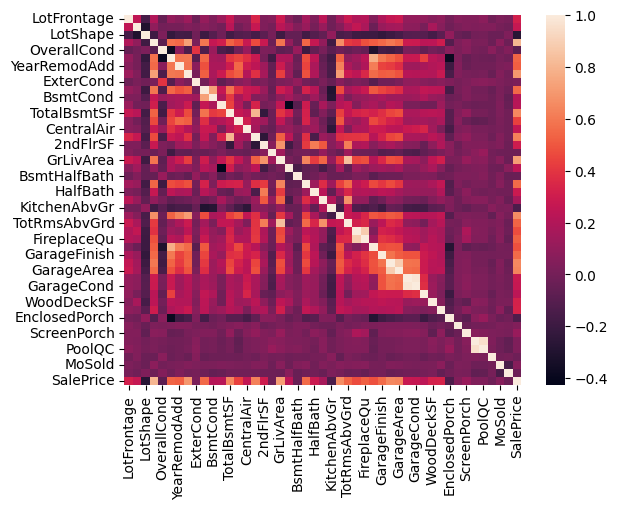

In [8]:
# print(data.info(verbose=True))

sb.heatmap(data.iloc[:, :47].corr())

In [9]:
y = data["SalePrice"]
y = data["PricePerLivArea"]
X = data.drop("SalePrice", axis="columns")
X = X.drop("PricePerLivArea", axis="columns")



In [11]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

reg = linear_model.LinearRegression()
_ = reg.fit(X, y)

y_pred = reg.predict(X)
mean_squared_error(y, y_pred)

147.54542090057964

In [12]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

reg = linear_model.Ridge(alpha=.5)
_ = reg.fit(X, y)

y_pred = reg.predict(X)
y_pred = y_pred * data["GrLivArea"]
mean_squared_error(y * data["GrLivArea"], y_pred)

402007777.9168328

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=SEED)
reg = linear_model.Ridge(alpha=.5)
_ = reg.fit(X_train, y_train)
print(reg.score(X_test, y_test))
y_pred_ridge = reg.predict(X_test)

reg = linear_model.LinearRegression()
_ = reg.fit(X_train, y_train)
print(reg.score(X_test, y_test))

y_pred_linear = reg.predict(X_test)

0.8227581388749201
0.8091129089518304


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=SEED)
reg = HistGradientBoostingRegressor()
_ = reg.fit(X_train, y_train)
print(reg.score(X_test, y_test))
y_pred_hist = reg.predict(X_test)

0.8426558343960104


In [15]:
from sklearn.model_selection import cross_validate

reg = linear_model.Ridge(alpha=1.0)
result = cross_validate(reg, X, y)
print(result["test_score"])
print(sum(result["test_score"]) / 5)

[0.80268774 0.77182902 0.76878234 0.79053506 0.79888125]
0.7865430826167874


In [16]:
from sklearn.model_selection import cross_validate

reg = linear_model.LinearRegression()
result = cross_validate(reg, X, y)
print(result["test_score"])
print(sum(result["test_score"]) / 5)

[0.79044572 0.74180085 0.74171139 0.77465522 0.79057491]
0.7678376161951427


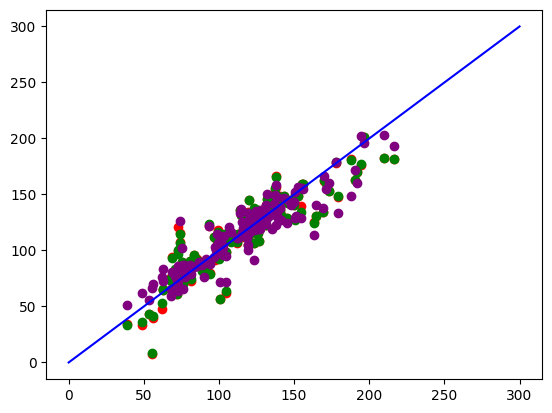

In [17]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_linear, color="red")
plt.scatter(y_test, y_pred_ridge, color="green")
plt.scatter(y_test, y_pred_hist, color="purple")

plt.plot([0, 300], [0, 300], color="blue")
plt.show()